In [1]:
import pandas as pd
data = pd.read_csv("../data/data_preprossing.csv")
data.shape

(652, 13)

In [2]:
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

X = data.drop(["List Price","IPO_Name","Date","Listing Gain","CMP(BSE)","CMP(NSE)","Current Gains"], axis=1)
y = data["List Price"]

X_train,X_test,y_train,y_test = train_test_split(X,y , test_size = 0.20 , random_state = 1)

model = XGBRegressor(random_state = 1)
model.fit(X_train ,y_train)
xg_pred = model.predict(X_test)

print(xg_pred[:10])

[ 18.48833   70.85567   81.389404 103.60223  584.4508   123.63368
 296.4963   588.96436  769.17334  222.63533 ]


In [3]:
comperison = pd.DataFrame({
    "Actual price" : y_test,
    "predicted price" : xg_pred
})
print(comperison)

     Actual price  predicted price
465         10.10        18.488331
441         55.80        70.855667
593         52.13        81.389404
458        110.00       103.602226
41         660.00       584.450806
..            ...              ...
195        360.50       361.157562
135        137.75       126.666389
411        313.00       352.305328
159        163.30       114.239136
250        141.00       107.304497

[131 rows x 2 columns]


In [4]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, xg_pred)
rmse = np.sqrt(mean_squared_error(y_test, xg_pred))
r2 = r2_score(y_test, xg_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 55.06635485059432
RMSE: 96.49337251551736
R2  : 0.9482088424470487


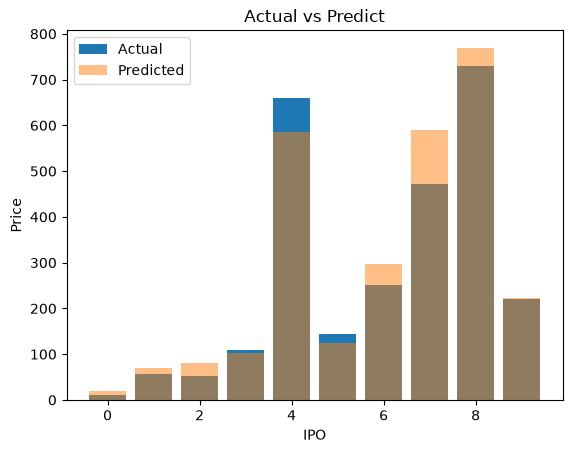

In [5]:
import matplotlib.pyplot as plt

plt.Figure(figsize=(10,6))

plt.bar(range(10), y_test[:10], label="Actual")
plt.bar(range(10), xg_pred[:10], alpha=0.5, label="Predicted")

plt.xlabel("IPO")
plt.ylabel("Price")
plt.title("Actual vs Predict")
plt.legend()

plt.show()

In [6]:
import joblib
joblib.dump(model ,"Xgboost.pkl")

['Xgboost.pkl']